# Imports

In [1]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional, Any, Literal
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import concurrent.futures
import gc

# from interval_timeline import CallGraph
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
import time
import datetime
import multiprocessing
from scipy.signal import savgol_filter, medfilt

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt
from collections import defaultdict


TEXLIVE_BIN_DIR = "/sw/frontier/spack-envs/base/opt/linux-sles15-x86_64/gcc-7.5.0/texlive-20220321-m56xupci4mc7hwbmnqy4oovch5pc7rrd/bin/x86_64-linux"
if TEXLIVE_BIN_DIR not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + TEXLIVE_BIN_DIR
    print(f"Successfully added TexLive directory to PATH.")
else:
    print("TexLive directory was already in PATH.")

plt.rcParams['text.usetex'] = True

FONT_SIZE = 20
plt.rcParams.update({
    'axes.labelsize': FONT_SIZE * 0.95,        # Font size of the x and y labels
    'xtick.labelsize': FONT_SIZE * 0.9, # Font size for x-axis tick labels
    'ytick.labelsize': FONT_SIZE * 0.9, # Font size for y-axis tick labels
    # 'legend.fontsize': FONT_SIZE * 0.7,       # Font size of the legend
})

Successfully added TexLive directory to PATH.


In [2]:
# Track how long the notebook takes to run
NOTEBOOK_START_TIME = time.time()
print(f"Notebook started at {NOTEBOOK_START_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_START_TIME)})")

Notebook started at 1767627626.8659368 (2026-01-05 10:40:26.865937)


# Preamble

### Define The Name of the Cluster & Trace Paths

Define the name of the cluster and the paths to the trace files.
This is needed to parse the trace directory paths correctly as generated by the master run script.

In [3]:
# CLUSTER_NAME = "frontier"

# ROOT_TRACE_DIR = "/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results"

### Define Which Ranks Run on Each Node

Define the topology of the runs. This is needed to attribute energy consumption correctly. Metrics are gathered at the node level, so we
need to know which node each rank ran on to get the metrics associated with that node + rank.

In [4]:
MI250X_HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
}
MI250X_HPG_NODE_RANKS = MI250X_HPL_NODE_RANKS

MI300A_HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']
}
MI300A_HPG_NODE_RANKS = MI300A_HPL_NODE_RANKS

### Define The Metrics to Attribute to Each Rank

This defines which MPI rank is on which GCD (frontier) or APU (el capitan). Two ranks drawing from the same GPU (each GPU has 2 GCDs) will have their energy consumption estimated independently based on their exclusive runtime.

In [5]:
MI250X_HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 4': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 5': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 6': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 7': ['A2rocm_smi:::energy_count:device=0'],
}
MI300A_HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3'],
}

MI250X_HPG_RANKS_TO_METRICS = MI250X_HPL_RANKS_TO_METRICS
MI300A_HPG_RANKS_TO_METRICS = MI300A_HPL_RANKS_TO_METRICS

### Define Which Metrics to Track in the Traces

This defines the metrics we're going to pay attention to when parsing the traces.
All metrics that are used above must be included here.

In [6]:

METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=1',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=3',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2rocm_smi:::current_socket_power:device=0',
    'A2rocm_smi:::current_socket_power:device=1',
    'A2rocm_smi:::current_socket_power:device=2',
    'A2rocm_smi:::current_socket_power:device=3',
    
    'A2rocm_smi:::power_average:device=0:sensor=0',
    'A2rocm_smi:::power_average:device=1:sensor=0',
    'A2rocm_smi:::power_average:device=2:sensor=0',
    'A2rocm_smi:::power_average:device=3:sensor=0',
    'A2rocm_smi:::power_average:device=4:sensor=0',
    'A2rocm_smi:::power_average:device=6:sensor=0',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',

    'A2coretemp:::craypm:memory_energy',
    'A2coretemp:::craypm:memory_power',
    'A2coretemp:::craypm:cpu_energy',
    'A2coretemp:::craypm:cpu_power',
    'A2coretemp:::craypm:energy',
    'A2coretemp:::craypm:power',
]

In [7]:
def process_dirname(dirroot: str, dirname: str) -> Optional[Tuple[str, str]]:
    if 'trial' not in dirname.lower():
        return None
    if 'rochplmxp' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('ROCHPL_MXP', full_path)
    elif 'rochpl' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('ROCHPL', full_path)
    elif '--run_type=standalone_mxp' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('HPG_MXP', full_path)
    elif '--run_type=standalone_ref' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('HPG', full_path)
    return None

# def convert_trace_to_csv(trace_path: str):
#     if os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace_path} --metrics="A2coretemp:::craypm:memory_power,A2coretemp:::craypm:memory_energy,A2coretemp:::craypm:power,A2coretemp:::craypm:energy,A2coretemp:::craypm:freshness,A2coretemp:::craypm:cpu_energy,A2coretemp:::craypm:cpu_power,A2coretemp:::craypm:accel0_energy,A2coretemp:::craypm:accel0_energy_timestamp,A2coretemp:::craypm:accel0_power,A2coretemp:::craypm:accel1_energy,A2coretemp:::craypm:accel1_energy_timestamp,A2coretemp:::craypm:accel1_power,A2coretemp:::craypm:accel2_energy,A2coretemp:::craypm:accel2_energy_timestamp,A2coretemp:::craypm:accel2_power,A2coretemp:::craypm:accel3_energy,A2coretemp:::craypm:accel3_energy_timestamp,A2coretemp:::craypm:accel3_power,A2rocm_smi:::energy_count:device=0,A2rocm_smi:::energy_count:device=2,A2rocm_smi:::energy_count:device=4,A2rocm_smi:::energy_count:device=6,A2rocm_smi:::gpu_clk_freq_System:device=0:current,A2rocm_smi:::gpu_clk_freq_System:device=2:current,A2rocm_smi:::gpu_clk_freq_System:device=4:current,A2rocm_smi:::gpu_clk_freq_System:device=6:current,A2rocm_smi:::temp_current:device=0:sensor=1,A2rocm_smi:::temp_current:device=2:sensor=1,A2rocm_smi:::temp_current:device=4:sensor=1,A2rocm_smi:::temp_current:device=6:sensor=1,A2rocm_smi:::power_average:device=0:sensor=0,A2rocm_smi:::power_average:device=2:sensor=0,A2rocm_smi:::power_average:device=4:sensor=0,A2rocm_smi:::power_average:device=6:sensor=0,A2rocm_smi:::memory_busy_percent:device=0,A2rocm_smi:::memory_busy_percent:device=2,A2rocm_smi:::memory_busy_percent:device=4,A2rocm_smi:::memory_busy_percent:device=6,A2rocm_smi:::busy_percent:device=0,A2rocm_smi:::busy_percent:device=2,A2rocm_smi:::busy_percent:device=4,A2rocm_smi:::busy_percent:device=6" --outputDir={os.path.dirname(trace_path)} > /dev/null 2>&1'):
#         raise RuntimeError(f"Failed to convert trace {trace_path} to CSV")

def get_trace_paths(root_dir: str) -> Dict[str, List[str]]:
    trace_paths = defaultdict(list)

    # Parallelized:
    for dirname in tqdm(os.listdir(root_dir), desc="Top-level directories"):
        dirpath = os.path.join(root_dir, dirname)
        if not os.path.isdir(dirpath):
            continue
        dirnames = os.listdir(dirpath)
        dirnames = [d for d in dirnames if os.path.isdir(os.path.join(dirpath, d))]
        if not dirnames:
            continue
        if 'rochpl' not in dirpath.lower() and 'xhpgmp' not in dirpath.lower():
            continue
        with multiprocessing.Pool(processes=os.cpu_count() or 16) as pool:
            results = pool.starmap(process_dirname, [(dirpath, dirname) for dirname in dirnames])
            for result in results:
                if result is not None:
                    benchmark_name, full_path = result
                    trace_paths[benchmark_name].append(full_path)

    # for dirname in tqdm(os.listdir(root_dir), desc="Converting traces to CSV"):
    #     if not os.path.isdir(os.path.join(root_dir, dirname)):
    #         continue
    #     dirroot = os.path.join(root_dir, dirname)
    #     # for trialdir in tqdm(os.listdir(dirroot), desc="Trial directories", leave=False):
    #     #     # Check if there's an OTF2 file and no CSV files
    #     #     trace = os.path.join(dirroot, trialdir, 'traces.otf2')
    #     #     if not os.path.exists(trace):
    #     #         continue
    #     #     if os.path.exists(os.path.join(dirroot, trialdir, 'MPI Rank 0_Master_thread_callgraph.csv')):
    #     #         continue
    #     #     # Convert the trace to CSV
    #     #     os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_TRACK)}" --outputDir={os.path.dirname(trace)} > /dev/null 2>&1')
    #     # Do it in parallel instead
    #     dirnames = os.listdir(dirroot)
    #     dirnames = [d for d in dirnames if os.path.isdir(os.path.join(dirroot, d))]
    #     if not dirnames:
    #         continue
    #     with multiprocessing.Pool(processes=8) as pool:
    #         pool.map(
    #             # lambda trialdir: os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={os.path.join(dirroot, trialdir, "traces.otf2")} --metrics="{",".join(METRICS_TO_TRACK)}" --outputDir={os.path.join(dirroot, trialdir)} > /dev/null 2>&1') 
    #             convert_trace_to_csv,
    #             # [os.path.join(dirroot, trialdir, 'traces.otf2') for trialdir in dirnames if os.path.exists(os.path.join(dirroot, trialdir, 'traces.otf2'))]
    #             [os.path.join(dirroot, trialdir, 'traces.otf2') for trialdir in dirnames if os.path.exists(os.path.join(dirroot, trialdir, 'traces.otf2')) and not os.path.exists(os.path.join(dirroot, trialdir, 'MPI Rank 0_Master_thread_callgraph.csv'))]
    #         )
    
    # Wait for all processes to finish
    # for process in tqdm(processes, desc="Converting traces to CSV"):
    #     process.join()

    return trace_paths

print("Collecting MI250X paths...")
if 'MI250X_TRACES' not in globals():
    # MI250X_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results")
    MI250X_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power")
print("Collecting MI300A trace paths...")
if 'MI300A_TRACES' not in globals():
    MI300A_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/results-mi300a-organized")

print(MI250X_TRACES)
print({k: len(v) for k, v in MI250X_TRACES.items()})
print(MI300A_TRACES)
print({k: len(v) for k, v in MI300A_TRACES.items()})

Top-level directories: 100%|██████████| 204/204 [00:10<00:00, 19.29it/s]


Top-level directories: 100%|██████████| 108/108 [00:09<00:00, 11.60it/s]

defaultdict(<class 'list'>, {'ROCHPL_MXP': ['/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_3-frontier08146-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_1-frontier09214-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_2-frontier08061-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_1-frontier00252-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-memory-power/rochplmxp-r8--P_1_-Q_8_-N_245760/trial_3-frontier06528-r8-rochplmxp--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-results-with-mem

### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [8]:
# # def callgraph_to_csv(call_graph: CallGraph, group: str, thread: str, filename: str):
# #     """Convert a CallGraph to a CSV file."""
# #     with open(filename, 'w') as f:
# #         f.write("Thread,Group,Depth,Name,Start Time,End Time,Duration\n")
# #         intervals = call_graph.get_intervals_between(float('-inf'), float('inf'))
        
# #         for interval in intervals:
# #             start = interval.start
# #             end = interval.end or float('inf')
# #             duration = end - start
# #             name = interval.name if interval.name else "Unknown"
# #             depth = interval.depth if interval.depth else 0

# #             f.write(f"{thread},{group},{depth},\"{name}\",{start},{end},{duration}\n")

# def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
#     """Convert metrics to a CSV file."""
#     with open(filename, 'w') as f:
#         f.write("Group,Metric Name,Time,Value\n")
#         for metric_name, values in thread_metrics.items():
#             for time, value in values:
#                 f.write(f"{group},{metric_name},{time},{value}\n")

# def read_metrics_dataframe(file: str) -> pd.DataFrame:
#     print(f"Reading metrics from {file}...")
#     df = pd.read_csv(file)
#     df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
#     # For all the rocm metrics, divide by 1e6 to convert from uJ to J
#     for metric_name in df['Metric Name'].unique():
#         if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
#             df['Value'] = df['Value'].astype(float)
#             df['Value'] = df['Value'].fillna(0.0)
#             df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
#     return df


#     # df = dd.read_csv(file)
#     # df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
#     # for metric_name in df['Metric Name'].unique():
#     #     if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
#     #         # First, fill all NaN values with 0
#     #         df['Value'] = df['Value'].astype(float)
#     #         df['Value'] = df['Value'].fillna(0.0)
#     #         # df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000.0
#     #         # Cant use loc with dask, so use mask
#     #         mask = (df['Metric Name'] == metric_name).astype('bool')
#     #         df['Value'] = df['Value'] / 1_000_000.0 * mask + df['Value'] * (~mask)
#     # return df.compute()

# def read_call_graph_dataframe(file: str) -> pd.DataFrame:
#     print(f"Reading call graph from {file}...")
#     return pd.read_csv(file)



# def read_optimized_metrics(path: str) -> pd.DataFrame:
#     dtype_map = {
#         'Group': 'category',
#         'Metric Name': 'category',
#         # 'Time': 'float64',
#         # 'Value': 'int64' # Int64 for precision
#     }
#     return pd.read_csv(path, dtype=dtype_map, engine='c')

# def read_optimized_callgraph(path: str) -> pd.DataFrame:
#     dtype_map = {
#         'Thread': 'category',
#         'Group': 'category',
#         'Depth': 'uint32',
#         'Name': 'category',
#         # 'Start Time': 'float64',
#         # 'End Time': 'float64',
#         # 'Duration': 'float64'
#     }
#     return pd.read_csv(path, dtype=dtype_map, engine='c')

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Group': 'category',
        'Metric Name': 'category',
        'Time': 'float64',
        'Value': 'int64' # Int64 for precision
    }
    df = pd.read_csv(file, dtype=dtype_map)
    df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
            df['Value'] = df['Value'].astype(float)
            df['Value'] = df['Value'].fillna(0.0)
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Thread': 'category',
        'Group': 'category',
        'Depth': 'uint32',
        'Name': 'category',
        'Start Time': 'float64',
        'End Time': 'float64',
        'Duration': 'float64'
    }
    return pd.read_csv(file, dtype=dtype_map)


### Remove Conflicting CSVs
Remove any existing CSVs that might conflict with new ones to be generated.

In [9]:
# # Remove all the old CSV files
# for file in os.listdir('.'):
#     if file.endswith('.csv'):
#         os.remove(file)

### Setup for Loading Traces
Convert an OTF2 to a CSV dataset to be loaded into a dataframe

In [10]:
# # Walk the root trace dir and convert all OTF2 traces to CSV using trace_to_csv_parallel
# for dirpath, dnames, filenames in tqdm(os.walk(ROOT_TRACE_DIR)):
#     trace = os.path.join(dirpath, 'traces.otf2')
#     if not os.path.exists(trace):
#         continue
#     if os.path.exists(os.path.join(dirpath, 'MPI Rank 0_Master_thread_callgraph.csv')):
#         continue
#     cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_ATTRIBUTE)}" --outputDir={os.path.dirname(trace)} > /dev/null 2>&1'
#     os.system(cmd)
    
    
#     # trace = trace[0]
#     # if not trace.endswith(".otf2"):
#     #     print("Skipping:", trace)
#     #     continue
#     # print(f"Processing trace: {trace}")
#     # cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh && ./trace_to_csv_parallel --trace={trace} --metrics="{",".join(METRICS_TO_ATTRIBUTE)}" --outputDir={os.path.dirname(trace)}'
#     # print(cmd)
#     # os.system(cmd)

In [11]:
# def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str] = METRICS_TO_ATTRIBUTE, cray_time_offset=0.0):
#     # Remove all the old CSV files
#     for file in os.listdir('.'):
#         if file.endswith('.csv'):
#             os.remove(file)
#     # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
#     print(f'Tracking metrics: {metrics_to_track}')
#     # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
#     cmd = f'./trace_to_csv_parallel --trace={trace} --metrics="{",".join(metrics_to_track)}"'
#     # Add the shared library path for OTF2
#     cmd = f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh && ' + cmd
#     os.system(cmd)

def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str] = METRICS_TO_TRACK, cray_time_offset=0.0):
    pass
    # # Remove all the old CSV files
    # for file in os.listdir('.'):
    # 	if file.endswith('.csv'):
    # 		os.remove(file)
    # # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
    # print(f'Tracking metrics: {metrics_to_track}')
    # # Shell out to ./trace_to_csv_parallel binary with `./trace_to_csv_parallel --tracePath=/path/to/trace.otf2`
    # cmd = f'./trace_to_csv_parallel --trace={trace} --metrics="{",".join(metrics_to_track)}"'
    # os.system(cmd)
    # Instead of getting the OTF2 trace and producing a CSV, we get the CSVs directly from the provided trace path    
    # So, copy the files from the same trace to the current directory. This means getting everything before `MPI Rank ...` in the trace path
    # And copying the matching files to the current directory
    # Get everything up to `MPI Rank ...` in the trace path
    # print('Getting prefix from:', trace)
    # trace_base = re.match(rf"^(.*)MPI Rank \d+", trace).group(1)
    
    # print(f'Copying files from trace base: {trace}')
    
    # # Get all the files in the trace base directory
    # all_files = os.listdir(trace)
    # # Copy them to the current directory if they match the processes to track
    # for file in all_files:
    #     dst = file
    #     # Trim off everything up to `MPI Rank ...` in the filename
    #     start = dst.find('MPI Rank')
    #     if start != -1:
    #         dst = dst[start:]
        
    #     if os.system(f'cp \"{os.path.join(trace, file)}\" \"{dst}\"'):
    #         # print(f"File {file} does not exist in trace {trace}.")
    #         break
    #     # else:
    #     #     print(f'Copied {dst} from trace {trace} to current directory.')
    
    # for process in processes_to_track:
    #     # Copy metrics CSV
    #     # metrics_src = f"{trace_base}{process}*.csv"
    #     # Perform the glob
    #     glob_pattern = f"{trace_base}{process}*.csv"
    #     files = [f for f in os.listdir(os.path.dirname(trace_base)) if re.match(rf"{os.path.basename(trace_base)}{re.escape(process)}.*\.csv", f)]
    #     for file in files:
    #         metrics_src = os.path.join(os.path.dirname(trace_base), file)
    #         # metrics_dst = f"."
    #         # Get only only the `MPI Rank ..._metrics.csv` part of the filename
    #         metrics_dst = file
    #         # Trip everything before `MPI Rank ...` in the filename
    #         metrics_dst = re.sub(rf"^.*?(MPI Rank \d+.*)", r"\1", metrics_dst)
    #         print(f'Copying {metrics_src} to {metrics_dst}')
    #         if os.system(f'cp \"{metrics_src}\" \"{metrics_dst}\"'):
    #             print(f"CSV files at {metrics_src} does not exist.")
    #         else:
    #             print(f"Copied {metrics_src} to {metrics_dst}")


# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))


### Math Helpers

Helpers for linearly interpolating values and computing numerical integrals + derivatives

In [12]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        f_end = f_np(x_pos)
        f_start = u[idx]

        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        return result.item() if np.isscalar(x) else result
    
    return F
        
def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f
        
def continuous_savgol_filter(f, window_length=11, polyorder=2, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        y_smooth = savgol_filter(y_samples, window_length=window_length, polyorder=polyorder, mode='nearest')
        return np.interp(t, t_samples, y_smooth)
    return f_smooth

def continuous_savgol_derivative(f, window_length=15, polyorder=3, sample_rate=0.001):
    def f_prime(t):
        t = np.asarray(t)
        
        t_min = t.min()
        t_max = t.max()
        
        # Handle edge case: if t is a single point or range is smaller than window
        if (t_max - t_min) < (window_length * sample_rate):
            pad = (window_length * sample_rate) / 2
            t_min -= pad
            t_max += pad

        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        
        # Sample the input function
        y_samples = f(t_samples)
        
        # deriv=1: Calculate 1st derivative (Slope)
        # delta=sample_rate: Scales the derivative by time (dy/dt)
        # mode='interp' or 'nearest': Handles boundaries
        y_deriv = savgol_filter(
            y_samples, 
            window_length=window_length, 
            polyorder=polyorder, 
            deriv=1, 
            delta=sample_rate, 
            mode='nearest'
        )
        
        # Interpolate back to the specific query times 't'
        return np.interp(t, t_samples, y_deriv)
        
    return f_prime
        
def continous_median_filter(f, kernel_size=11, sample_rate=0.001):
    def f_smooth(t):
        t = np.asarray(t)
        t_min = t.min()
        t_max = t.max()
        t_samples = np.arange(t_min, t_max + sample_rate, sample_rate)
        y_samples = f(t_samples)
        y_smooth = medfilt(y_samples, kernel_size=kernel_size)
        return np.interp(t, t_samples, y_smooth)
    return f_smooth        

def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [13]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    df = df.sort_values(by='Start Time')
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [14]:
class Rank:
    def __init__(self, node: str, name: str, call_graph: pd.DataFrame):
        self.node = node
        self.name = name
        self.call_graph = call_graph
        assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
        
    def get_all_code_regions(self) -> List[str]:
        return self.call_graph['Name'].unique().tolist()

    def compute_attribution(
        self,
        metrics_accumulated: Dict[str, callable],
        duration_threshold: float = 0.001,
        weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
        df = self.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        df = df[~pref3.isin(['hip', 'mpi'])]

        if df.empty:
            return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'].to_numpy()
        names  = df['Name'].to_numpy()

        cols = {}
        for metric, f in metrics_accumulated.items():
            try:
                deltas = f(ends) - f(starts)
                deltas = np.asarray(deltas, dtype=float)
                deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception:
                deltas = np.fromiter(
                    (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                    dtype=float, count=len(starts)
                )

            if weights_by_metric and metric in weights_by_metric:
                w = np.asarray(weights_by_metric[metric], dtype=float)
                if w.shape[0] == deltas.shape[0]:
                    deltas = deltas * w
                elif w.size == 1:
                    deltas = deltas * float(w)
                else:
                    deltas = deltas * 1.0

            cols[metric] = deltas

        out = pd.DataFrame(cols)
        out['Code Region'] = names
        out = out.groupby('Code Region', as_index=False).sum()
        return out

    def refresh(self):
        return Rank(self.node, self.name, self.call_graph)

    def __str__(self):
        return f"Rank({self.name})"

def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
    """
    For each segment [breaks[i], breaks[i+1]), return a dict:
      masks[region_name][i] = True  iff the region is on the call stack
                                   (ancestor of top-of-stack) for the ENTIRE segment.
    Assumptions:
      - breaks includes all start/end times (so inside a segment no boundary occurs).
      - 'depths' is 0-based, increasing with nesting.
    """
    seg_count = breaks.size - 1
    masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

    lefts, rights = breaks[:-1], breaks[1:]
    for i in range(seg_count):
        L, R = lefts[i], rights[i]

        # Regions that cover the whole segment (active across the entire segment)
        idx = np.where((s <= L) & (e >= R))[0]
        if idx.size == 0:
            continue

        # Top of stack depth
        dmax = depths[idx].max()

        # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
        # (there should typically be at most one per depth due to proper nesting)
        for d in range(dmax + 1):
            cand = idx[depths[idx] == d]
            if cand.size:
                # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
                # here cand already covers segment; pick the first deterministically.
                j = cand[0]
                masks[names[j]][i] = True

    return masks

class Node:
    def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
        self.name = name
        self.ranks = ranks
        self.metrics = metrics_df
        assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

    def refresh(self):
        return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

    def get_metric_names(self) -> List[str]:
        return self.metrics['Metric Name'].unique().tolist()
    
    def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
        return self.metrics[self.metrics['Metric Name'] == metric_name]

    def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
        df = rank.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        # df = df[~pref3.isin(['hip', 'mpi'])]
        # Finite and non-degenerate
        mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
        df = df[mfin & (df['End Time'] > df['Start Time'])]
        return df

    # ---- NEW CORE HELPER: inclusive vs exclusive controlled by flag ----
    def _compute_attribution_core(
        self,
        ranks_to_metrics: Dict[str, List[str]],
        instantaneous_metrics = [],
        duration_threshold: float = 0.0,
        inclusive: bool = True,
    ):
        used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
        if not used_metrics:
            return pd.DataFrame(columns=['Code Region'])

        metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
        metrics_accumulated = {
            m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
            for m in used_metrics
        }

        rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
        rank_events = {
            rname: (
                df['Start Time'].to_numpy(),
                df['End Time'].to_numpy(),
                df['Name'].to_numpy(),
                df['Depth'].astype(int).to_numpy()
            )
            for rname, df in rank_df.items()
        }

        metric_to_ranks: Dict[str, List[str]] = {}
        for rname, mlist in ranks_to_metrics.items():
            for m in mlist:
                metric_to_ranks.setdefault(m, []).append(rname)

        rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

        for metric in used_metrics:
            f = metrics_accumulated[metric]
            rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
            if not rnames:
                continue

            all_s, all_e = [], []
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size:
                    all_s.append(s); all_e.append(e)
            if not all_s:
                continue

            S_concat = np.concatenate(all_s)
            E_concat = np.concatenate(all_e)
            breaks = np.unique(np.concatenate([S_concat, E_concat]))
            breaks = breaks[np.isfinite(breaks)]
            if breaks.size < 2:
                continue
            seg_count = breaks.size - 1

            # dE per segment
            try:
                E_vals = f(breaks)
                E_vals = np.asarray(E_vals, dtype=float)
                if E_vals.shape != breaks.shape:
                    raise ValueError
            except Exception:
                print(f"Warning: Non-vectorized metric function for metric {metric}, falling back to loop.")
                E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

            dE = E_vals[1:] - E_vals[:-1]
            dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
            dE = np.maximum(dE, 0.0)

            # Which ranks are active in each segment?
            active_by_rank: Dict[str, np.ndarray] = {}
            lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

            zeros_seg = np.zeros(seg_count, dtype=bool)
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size == 0:
                    active_by_rank[rn] = zeros_seg
                    lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
                    continue

                L = np.searchsorted(breaks, s, side='right') - 1
                R = np.searchsorted(breaks, e, side='left') - 1
                valid = (R >= L) & (R >= 0) & (L < seg_count)
                L = np.clip(L[valid], 0, seg_count - 1)
                R = np.clip(R[valid], 0, seg_count - 1)

                lr_by_rank[rn] = (L, R)

                # coverage count via difference array
                diff = np.zeros(seg_count + 1, dtype=int)
                for l, r in zip(L, R):
                    diff[l] += 1
                    diff[r + 1] -= 1
                c = np.cumsum(diff[:-1])
                active_by_rank[rn] = (c > 0)

            # k(t): number of active ranks per segment
            k = np.zeros(seg_count, dtype=int)
            for rn in rnames:
                k += active_by_rank[rn].astype(int)

            # Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
            share_per_seg = np.zeros_like(dE, dtype=float)
            mask_k = (k > 0)
            share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

            # --- Attribution per rank ---
            for rn in rnames:
                s, e, names, depths = rank_events[rn]
                if s.size == 0:
                    continue

                L, R = lr_by_rank[rn]
                if L.size == 0:
                    continue

                if inclusive:
                    masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        masks[names[j]][l:r+1] = True

                    for region_name, seg_mask in masks.items():
                        if not seg_mask.any():
                            continue
                        contrib = float(share_per_seg[seg_mask].sum())
                        if contrib == 0.0:
                            continue
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib
                else:
                    top_depth = np.full(seg_count, -1, dtype=int)
                    top_idx   = np.full(seg_count, -1, dtype=int)

                    # For each event j, mark segments [L[j], R[j]] and keep the deepest
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        d = depths[j]
                        seg_slice = slice(l, r + 1)

                        current_depths = top_depth[seg_slice]
                        mask = d >= current_depths
                        if not np.any(mask):
                            continue

                        # Update depths
                        current_depths[mask] = d
                        top_depth[seg_slice] = current_depths

                        # Update indices
                        current_idx = top_idx[seg_slice]
                        current_idx[mask] = j
                        top_idx[seg_slice] = current_idx

                    # Now attribute share_per_seg only to top-of-stack region per segment
                    for seg_i, j in enumerate(top_idx):
                        if j < 0:
                            continue  # rank not active here
                        contrib = float(share_per_seg[seg_i])
                        if contrib == 0.0:
                            continue
                        region_name = names[j]
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib

        # --- Convert to per-rank DataFrames and do a wide merge ---
        attribution = None
        for rank in self.ranks:
            rn = rank.name
            # Filter only the metrics requested for this rank
            wanted = ranks_to_metrics.get(rn, [])
            if not wanted:
                continue

            rows = []
            for region, mdict in rank_tables.get(rn, {}).items():
                row = {'Code Region': region}
                # Ensure a column for each requested metric
                for m in wanted:
                    row[m] = mdict.get(m, 0.0)
                rows.append(row)

            df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
            # Ensure columns if they are missing
            for m in wanted:
                if m not in df_rank.columns:
                    df_rank[m] = 0.0

            # Rename metrics with rank suffix to avoid collisions
            rename_map = {m: f"{m}_{rn}" for m in wanted}
            df_rank = df_rank.rename(columns=rename_map)

            # Outer merge on 'Code Region'
            attribution = df_rank if attribution is None else pd.merge(
                attribution, df_rank, on='Code Region', how='outer'
            )

        # If there was nothing, return minimal header
        if attribution is None:
            all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
            return pd.DataFrame(columns=all_cols)

        return attribution.fillna(0.0)

    def compute_attribution(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=True,
        )

    def compute_attribution_exclusive(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        """
        Exclusive attribution: for each segment and rank, only the *deepest*
        active region on the stack receives that segment's share of energy.
        """
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=False,
        )

    def __str__(self):
        return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
    def __init__(self, path: str, nodes: List[Node] = []):
        self.path = path
        self.nodes = nodes
        
    def refresh(self):
        return Run(self.path, [node.refresh() for node in self.nodes])

    @staticmethod
    def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
        # Load the trace dataframes for each node and its ranks
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        # trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        all_threads = []
        for _, ranks in node_ranks.items():
            all_threads.extend(ranks)
        result = {}
        # trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
        for node, ranks in node_ranks.items():
            if not os.path.exists(os.path.join(trace_path, f"{ranks[0]}_metrics.csv")):
                raise FileNotFoundError(f"Metrics file for rank {ranks[0]} does not exist in trace path {trace_path}.")
            metrics_df = read_metrics_dataframe(os.path.join(trace_path, f"{ranks[0]}_metrics.csv"))
            # print(f"Loaded metrics dataframe from {trace_path}")
            assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
            rank_callgraphs = []
            for rank in ranks:
                if os.path.exists(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv")):
                    call_graph = read_call_graph_dataframe(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv"))
                    assert call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
                    # Construct the Hatchet and Thicket graphs
                    rank_callgraphs.append(Rank(node, rank, call_graph))
                else:
                    raise FileNotFoundError(f"Call graph file for rank {rank} does not exist in trace path {trace_path}.")
            result[node] = Node(node, metrics_df, rank_callgraphs)
        return Run(trace_path, list(result.values()))

    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return attributions
    
    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing EXCLUSIVE attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return attributions
    
    def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
        for node in self.nodes:
            if node.name == node_name:
                return node.get_metric_samples(metric_name)
        raise ValueError(f"Node {node_name} not found in run.")
    
    def to_thicket(self, **metadata) -> tt.Thicket:
        thickets = []
        
        for node in self.nodes:
            # self.get_metric_samples(node)
            metric_functions = {}
            for metric_name in node.get_metric_names():
                metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
            
            for rank in node.ranks:
                print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
                dag = create_hatchet_dag(rank.call_graph, metric_functions)
                tf = tt.Thicket.from_literal(dag)
                # tf = tt.Thicket.from_literal(dag)
                print("Thicket created from DAG.")
                tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
                tf.metadata['rank'] = rank.name
                tf.metadata['node'] = node.name
                tf.metadata = tf.metadata.assign(**metadata)
                tf.metadata.index.name = tf.dataframe.index.names[1]
        
                thickets.append(tf)
        
        print(f"Total thickets created: {len(thickets)}")
        if thickets:
            print("Combining thickets...")
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        raise ValueError("No thickets were created from the run.")
        
    def __str__(self):
        return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
    def __init__(self, runs: List[Run]):
        self.runs = runs
        self.attributions = {}
        self.attributions_exclusive = {}
    
    @staticmethod
    def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
        return ensemble_from_trace_path_helper(trace_paths, node_ranks)
 
    def refresh(self):
        return Ensemble([run.refresh() for run in self.runs])
    
    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        if self.attributions != {}:
            print("Attributions already computed, returning cached results.")
            return self.attributions
        
        for run in self.runs:
            self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return self.attributions
 
    def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty: 
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region': 
                        continue
                    vals = df[metric].to_numpy()
                    # Extend in bulk (no per-iteration concatenations)
                    records.extend(
                        {'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)

    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        if self.attributions_exclusive != {}:
            print("Exclusive attributions already computed, returning cached results.")
            return self.attributions_exclusive
        
        for run in self.runs:
            run_name = os.path.basename(os.path.dirname(run.path))
            print(f"Computing EXCLUSIVE attribution for run {run_name}...")
            self.attributions_exclusive[run_name] = run.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return self.attributions_exclusive

    def compute_attribution_exclusive_across_runs(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
    ):
        attributions = self.compute_attribution_exclusive(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty:
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region':
                        continue
                    vals = df[metric].to_numpy()
                    records.extend(
                        {
                            'Run': run_name,
                            'Node': node_name,
                            'Code Region': c,
                            'Metric': metric,
                            'Value': v,
                        }
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)
    
    def to_thicket(self) -> tt.Thicket:
        thickets = []
        for run in self.runs:
            name = os.path.basename(os.path.dirname(run.path))
            print(f"Creating Thicket for run {run.path} ({name})...")
            tf = run.to_thicket(trace=run.path, run=name)
            thickets.append(tf)
        if thickets:
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        else:
            return tt.Thicket()


_global_executor = None

def get_threadpool(max_workers=None):
    global _global_executor
    if _global_executor is None:
        max_workers = max_workers or min(os.cpu_count(), 256)
        # print(f"Initializing global thread pool with {max_workers} workers...\r")
        _global_executor = ProcessPoolExecutor(max_workers=max_workers)
    return _global_executor

def run_from_trace_path_helper(args) -> Run:
    path, node_ranks = args
    return Run.from_trace_path(path, node_ranks)

def _load_metrics(args):
    path, node, mpath = args
    if not os.path.exists(mpath):
        raise FileNotFoundError(f"Metrics file {mpath} missing.")
    df = read_metrics_dataframe(mpath)
    assert df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Bad metrics columns in {mpath}: {df.columns.tolist()}"
    return path, node, df

def _load_callgraph(args):
    path, node, rank, cpath = args
    if not os.path.exists(cpath):
        raise FileNotFoundError(f"Call graph file {cpath} missing.")
    df = read_call_graph_dataframe(cpath)
    assert df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Bad callgraph columns in {cpath}: {df.columns.tolist()}"
    return path, node, rank, df

def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
    # Flatten all work across all runs (trace_to_csv + metrics + callgraphs)
    for path in trace_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Trace path {path} does not exist.")
    all_threads = [rank for ranks in node_ranks.values() for rank in ranks]

    exec_csv = get_threadpool(128)

    # Build tasks for metrics (one per (run,node)) and callgraphs (one per (run,node,rank))
    metrics_tasks = []
    callgraph_tasks = []
    for path in trace_paths:
        for node, ranks in node_ranks.items():
            metrics_tasks.append((path, node, os.path.join(path, f"{ranks[0]}_metrics.csv")))
            for rank in ranks:
                callgraph_tasks.append((path, node, rank, os.path.join(path, f"{rank}_Master_thread_callgraph.csv")))

    exec_load = get_threadpool()
    fut_metrics = [exec_load.submit(_load_metrics, t) for t in metrics_tasks]
    fut_callgraphs = [exec_load.submit(_load_callgraph, t) for t in callgraph_tasks]

    metrics_by_run_node = defaultdict(dict)
    for f in tqdm(as_completed(fut_metrics), total=len(fut_metrics), desc="Loading metrics", leave=False):
        path, node, dfm = f.result()
        metrics_by_run_node[(path, node)] = dfm

    callgraph_by_run_node_rank = defaultdict(dict)
    for f in tqdm(as_completed(fut_callgraphs), total=len(fut_callgraphs), desc="Loading callgraphs", leave=False):
        path, node, rank, dfc = f.result()
        callgraph_by_run_node_rank[(path, node, rank)] = dfc

    # Assemble Run objects
    runs = []
    for path in trace_paths:
        node_objs = []
        for node, ranks in node_ranks.items():
            mdf = metrics_by_run_node.get((path, node))
            if mdf is None:
                raise ValueError(f"Missing metrics for run {path}, node {node}")
            rank_objs = []
            for rank in ranks:
                cdf = callgraph_by_run_node_rank.get((path, node, rank))
                if cdf is None:
                    raise ValueError(f"Missing callgraph for run {path}, node {node}, rank {rank}")
                rank_objs.append(Rank(node, rank, cdf))
            node_objs.append(Node(node, mdf, rank_objs))
        runs.append(Run(path, node_objs))
    
    return Ensemble(runs)

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()


def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return replace_prefix_and_suffix(match.group(0) if match else s)

In [18]:
def get_text_color(hex_color_or_rgb):
    """Determines if text should be black or white based on background luminance."""
    if isinstance(hex_color_or_rgb, str):
        rgb = mcolors.hex2color(hex_color_or_rgb)
    else:
        rgb = hex_color_or_rgb[:3]
    
    # Luminance formula
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.5 else 'white'

def visualize_power_of_runs_stacked_bar(
    runs_fp, # Type: Ensemble
    differentiate_rocm=True,
    name='',
    show_callgraph_events: str='full',
    run_count=1,
    tdp_line=None,
    rank_number=0,
    accel_type='GPU',
    prefix_replacements: list[tuple[str, str]] = [],
    combined_metrics={
        # 'Sum of Cray PM\nAccelerators': ['A2coretemp:::craypm:accel0_power', 'A2coretemp:::craypm:accel1_power', 'A2coretemp:::craypm:accel2_power', 'A2coretemp:::craypm:accel3_power'],
        # 'Sum of Cray PM\nAccelerators dE/dt': ['A2coretemp:::craypm:accel0_energy', 'A2coretemp:::craypm:accel1_energy', 'A2coretemp:::craypm:accel2_energy', 'A2coretemp:::craypm:accel3_energy'],
        'Sum of \\texttt{rocm-smi}\nCurrent Power': ['A2rocm_smi:::current_socket_power:device=0', 'A2rocm_smi:::current_socket_power:device=1', 'A2rocm_smi:::current_socket_power:device=2', 'A2rocm_smi:::current_socket_power:device=3', 'A2rocm_smi:::current_socket_power:device=4', 'A2rocm_smi:::current_socket_power:device=6'],
        'Sum of \\texttt{rocm-smi}\nAverage Power': ['A2rocm_smi:::power_average:device=0:sensor=0', 'A2rocm_smi:::power_average:device=2:sensor=0', 'A2rocm_smi:::power_average:device=4:sensor=0', 'A2rocm_smi:::power_average:device=6:sensor=0'],
    },
    combined_metric_colors={
        # 'Sum of Cray PM\nAccelerators': '#8B5CF6',  # Purple
        'Sum of \\texttt{rocm-smi}\nCurrent Power': '#10B981',  # Green
        'Sum of \\texttt{rocm-smi}\nAverage Power': '#10B981',  # Pink
    },
    run_info: List[str] = [],
):
    if not runs_fp.runs:
        return
    
    # if accel_type.lower() == 'gpu':
    #     # Remove the sum of accelerators combined metric if using GPUs
    #     if 'Sum of Cray PM\nAccelerators' in combined_metrics:
    #         del combined_metrics['Sum of Cray PM\nAccelerators']
    #         del combined_metric_colors['Sum of Cray PM\nAccelerators']

    # --- 1. Metric Setup ---
    node_metric = 'A2coretemp:::craypm:power'
    cpu_metric = 'A2coretemp:::craypm:cpu_power'
    memory_metric = 'A2coretemp:::craypm:memory_power'
    
    available_metrics = runs_fp.runs[0].nodes[0].metrics['Metric Name'].unique().tolist()
    potential_gpu_metrics = [f'A2rocm_smi:::energy_count:device={i}' for i in [0,1,2,3,4,6]]
    gpu_metrics = [m for m in potential_gpu_metrics if m in available_metrics]
    
    metrics_order = gpu_metrics + [cpu_metric, memory_metric, node_metric]

    # --- 2. Color Palette ---
    color_map = {}
    color_map[cpu_metric]    = '#3B82F6'  # Bright Blue
    color_map[memory_metric] = '#22D3EE'  # Cyan
    color_map[node_metric]   = '#111827'  # Black (Line)

    # Distinct GPU colors
    sunset_palette = [
        '#7F1D1D', # Deep Red
        '#DC2626', # Red
        '#EA580C', # Burnt Orange
        '#F59E0B', # Amber
        '#FACC15', # Yellow
        '#A16207', # Brown/Gold
    ]
    for i, m in enumerate(gpu_metrics):
        color_map[m] = sunset_palette[i % len(sunset_palette)]

    # --- 3. Figure Layout ---
    FIG_WIDTH = 13
    fig = plt.figure(figsize=(FIG_WIDTH, 8))
    
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.5], hspace=0.15)
    
    ax_gantt = fig.add_subplot(gs[0])
    ax_power = fig.add_subplot(gs[1], sharex=ax_gantt)
    
    title_prefix = (name + ' ') if name else ''

    # --- 4. Callgraph (Icicle Chart) ---
    max_global_time = 0

    if show_callgraph_events:
        first_run = runs_fp.runs[0]
        call_graph_df = first_run.nodes[0].ranks[rank_number].call_graph.copy()
        
        try:
            # Assuming take_alphanumeric is defined elsewhere in your scope
            call_graph_df['Name'] = call_graph_df['Name'].apply(take_alphanumeric)
        except NameError:
            pass 
            
        for old_p, new_p in prefix_replacements:
            call_graph_df['Name'] = call_graph_df['Name'].str.replace(old_p, new_p, regex=False)
        
        call_graph_df = call_graph_df[call_graph_df['Duration'] >= 0.001]
        call_graph_df = call_graph_df.sort_values(by=['Start Time', 'Duration'], ascending=[True, False])

        # Show a max depth of 8 to avoid overcrowding
        call_graph_df = call_graph_df[call_graph_df['Depth'] <= 8]

        if not call_graph_df.empty:
            # 60 distinct colors
            color_pool = plt.cm.Dark2.colors
            # Sort the functions by total duration to prioritize longer-running functions
            call_graph_df = call_graph_df.sort_values(by='Duration', ascending=False)
            unique_funcs = call_graph_df['Name'].unique()
            
            func_color_map = {}
            for i, func_name in enumerate(unique_funcs):
                func_color_map[func_name] = color_pool[i % len(color_pool)]

            # Darkened Panel Background
            ax_gantt.set_facecolor('#E5E5E5') 
            for spine in ax_gantt.spines.values():
                spine.set_visible(True)
                spine.set_color('#404040') 
            
            max_time = call_graph_df['End Time'].max()
            total_time_span = max_time - call_graph_df['Start Time'].min()

            # --- Heuristic for Text Fitting ---
            # Estimate usable axis width in inches (Figure width - margins)
            # Roughly 0.85 of the figure width is usable for the plot area
            EST_AXIS_WIDTH_INCHES = FIG_WIDTH * 0.85
            FONT_SIZE = 8
            # Monospace font aspect ratio is approx 0.6 (Width/Height)
            CHAR_WIDTH_INCHES = (FONT_SIZE / 72.0) * 0.6 

            for idx, row in call_graph_df.iterrows():
                start, dur = row['Start Time'], row['Duration']
                func_name, depth = row['Name'], row['Depth']
                c = func_color_map[func_name]
                
                ax_gantt.barh(
                    y=depth, width=dur, left=start, height=0.9, 
                    color=c, 
                    linewidth=0.0, align='center'
                )
                
                # --- NEW LABELS LOGIC ---
                # Calculate how wide the text is physically vs how wide the bar is physically
                text_width_inches = len(func_name) * CHAR_WIDTH_INCHES
                bar_width_inches = (dur / total_time_span) * EST_AXIS_WIDTH_INCHES
                
                # Only draw if the text is smaller than the bar width
                if text_width_inches < bar_width_inches:
                    txt_color = get_text_color(c)
                    ax_gantt.text(
                        start + (dur / 2), depth, func_name, 
                        ha='center', va='center', color=txt_color, 
                        fontsize=FONT_SIZE, fontweight='bold', 
                        clip_on=True,
                        family='monospace'
                    )

            ax_gantt.invert_yaxis()
            
            # Legend
            top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index
            patches = [mpatches.Patch(color=func_color_map[n], label=n) for n in top_funcs]
            leg = ax_gantt.legend(
                handles=patches, title="Key Regions", 
                loc='upper left', bbox_to_anchor=(1.005, 1), 
                frameon=False
            )
            plt.setp(leg.get_texts(), family='monospace')

    # --- 5. Stacked Power ---
    ax_power.set_facecolor('#E5E5E5') # Darker grey panel background
    ax_power.grid(True, axis='y', color='white', linestyle='-', linewidth=1, zorder=0)
    for spine in ax_power.spines.values():
        spine.set_visible(True)
        spine.set_color('#404040')

    current_max_y = 0

    for run_idx, run in enumerate(runs_fp.runs[:run_count]):
        power_funcs = {}
        time_arrays = {}

        for m in metrics_order:
            samples = run.get_metric_samples('node0', m)
            if samples is None or samples.empty: continue
            samples = samples.sort_values('Time')
            
            if differentiate_rocm and ('energy' in m.lower()):
                s = samples.copy()
                s['Value'] -= s['Value'].min()
                try:
                    # Assuming these helper functions exist in your scope
                    energy_fn = sampled_to_continuous(s)
                    power_fn = numerical_derivative(energy_fn)
                except NameError: 
                    continue
            else:
                try:
                    power_fn = sampled_to_continuous(samples)
                except NameError:
                    continue
                    
            power_funcs[m] = power_fn
            time_arrays[m] = samples['Time'].to_numpy()

        if not power_funcs: continue
        
        global_times = np.unique(np.concatenate(list(time_arrays.values())))
        global_times.sort()
        if len(global_times) < 2: continue
        
        max_global_time = max(max_global_time, global_times[-1])

        widths = np.diff(global_times, append=global_times[-1] + (global_times[-1] - global_times[-2]))
        bottom = np.zeros_like(global_times, dtype=float)

        gpu_idx = 1
        for m in metrics_order:
            if m not in power_funcs: continue
            try:
                vals = np.asarray(power_funcs[m](global_times))
            except:
                vals = np.asarray(power_funcs[m](pd.Series(global_times)))

            if m == cpu_metric: label = 'CPU'
            elif m == memory_metric: label = 'Memory'
            elif m == node_metric: continue 
            else:
                label = f'{accel_type} \\#{gpu_idx} dE/dt'
                gpu_idx += 1
                
            clip_value = np.percentile(vals, 99.9)
            vals = np.clip(vals, 0, clip_value)

            ax_power.bar(
                global_times, vals, width=widths, bottom=bottom,
                label=label if run_idx == 0 else None,
                color=color_map[m], 
                align='edge', 
                linewidth=0,
                zorder=3
            )
            bottom += vals
            
        if len(bottom) > 0:
            current_max_y = max(current_max_y, np.max(bottom))

        if node_metric in power_funcs:
            node_vals = np.asarray(power_funcs[node_metric](global_times))
            ax_power.plot(
                global_times, node_vals, 
                color=color_map[node_metric], 
                lw=1.5, 
                label='Total Node Power' if run_idx == 0 else None, 
                zorder=4
            )
            current_max_y = max(current_max_y, np.max(node_vals))

    if tdp_line:
        ax_power.axhline(y=tdp_line, color='#EF4444', linestyle='--', lw=2, label=f'Combined TDP', zorder=5)

    sorted_combined_metrics = sorted(combined_metrics.items(), key=lambda x: x[0])
    for combined_metric_label, component_metrics in sorted_combined_metrics:
        combined_y = np.zeros_like(global_times, dtype=float)
        found = False
        
        if not any(run.get_metric_samples('node0', m) is not None for m in component_metrics):
            continue
        
        for m in component_metrics:
            try:
                if m not in power_funcs:
                    power_funcs[m] = sampled_to_continuous(run.get_metric_samples('node0', m))
                    # if 'cray' in m.lower():
                    #     # Perform a median filter
                    #     # power_funcs[m] = continous_median_filter(power_funcs[m], sample_rate=0.1)
                    #     power_funcs[m] = numerical_derivative(power_funcs[m], h=0.1)
                        
                try:
                    vals = np.asarray(power_funcs[m](global_times))
                except:
                    vals = np.asarray(power_funcs[m](pd.Series(global_times)))

                found = True
                combined_y += vals
            except Exception as e:
                print(f"Could not add component metric {m} for combined metric {combined_metric_label}: {e}")
                continue
        if not found:
            continue
        ax_power.plot(
            global_times, combined_y, 
            color=combined_metric_colors[combined_metric_label],
            lw=1.5, 
            label=combined_metric_label, 
            zorder=6
        )
        
    # --- 6. Final Polish ---
    ax_power.set_ylabel('Power (W)', weight='bold')
    ax_power.set_xlabel('Time (s)',weight='bold')
    ax_gantt.set_ylabel("Call Stack\n(Rank \\#0)", labelpad=10, weight='bold')
    ax_gantt.set_yticks([]) 
    
    ax_power.set_xlim(0, max_global_time)
    ax_gantt.set_xlim(0, max_global_time)

    locator = ticker.MaxNLocator(nbins=15, integer=True)
    
    ax_gantt.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_power.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_gantt.xaxis.set_major_locator(locator)
    ax_power.xaxis.set_major_locator(locator)
    
    ax_gantt.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)
    ax_power.tick_params(axis='x', which='both', top=False, labeltop=False, bottom=True, labelbottom=True)

    # Get the total node energy used for the legend

    leg = ax_power.legend(
        ncol=1, loc='upper left', bbox_to_anchor=(1.005, 1),
        frameon=False, title="Hardware"
    )

    if run_info == []:
        # Add the total node energy used and GPU/APU energy if available
        first_run = runs_fp.runs[0]
        node_energy_samples = first_run.get_metric_samples('node0', 'A2coretemp:::craypm:energy')
        if node_energy_samples is not None and not node_energy_samples.empty:
            total_node_energy = node_energy_samples['Value'].iloc[-1] - node_energy_samples['Value'].iloc[0]
            run_info.append(f'Total Node Energy: {total_node_energy:.2f} J')
        gpu_energy_samples = []
        for i in [0,1,2,3,4,6]:
            s = first_run.get_metric_samples('node0', f'A2rocm_smi:::energy_count:device={i}')
            if s is not None and not s.empty:
                gpu_energy_samples.append(s)
        if gpu_energy_samples:
            total_gpu_energy = sum(s['Value'].iloc[-1] - s['Value'].iloc[0] for s in gpu_energy_samples)
            run_info.append(f'Total {accel_type} Energy: {total_gpu_energy:.2f} J')
    
    # Show a second legend *in* the power graph plot, top left, to show
    # the run info
    if run_info:
        run_info_text = "\n".join(run_info)
        ax_power.text(
            0.01, 0.98, run_info_text,
            transform=ax_power.transAxes,
            fontsize=14,
            verticalalignment='top',
            horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray'),
            zorder=10
        )

    filename = f'{title_prefix.strip().replace(" ", "_")}_stacked_power.png'
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

In [19]:
def calculate_energy_savings_dataframe(ensemble: Ensemble) -> pd.DataFrame:
    records = []
    for run in ensemble.runs:
        for node in run.nodes:
            record = {}
            # Whole node energy
            total_energy = 0.0
            energy_samples = node.get_metric_samples('A2coretemp:::craypm:energy')
            if not energy_samples.empty:
                sorted_samples = energy_samples.sort_values(by='Time')
                first_energy = sorted_samples.iloc[0]['Value']
                last_energy = sorted_samples.iloc[-1]['Value']
                total_energy = last_energy - first_energy
            record['Total Energy'] = total_energy

            # GPU energy
            gpu_energy = 0.0
            for i in range(8):  # Assuming up to 8 GPUs per node
                # metric_name = f'A2coretemp:::craypm:accel{i}_energy'
                metric_name = f'A2rocm_smi:::energy_count:device={i}'
                energy_samples = node.get_metric_samples(metric_name)
                if not energy_samples.empty:
                    sorted_samples = energy_samples.sort_values(by='Time')
                    first_energy = sorted_samples.iloc[0]['Value']
                    last_energy = sorted_samples.iloc[-1]['Value']
                    gpu_energy += (last_energy - first_energy)
            record['GPU Energy'] = gpu_energy

            # Memory energy
            memory_energy = 0.0
            energy_samples = node.get_metric_samples('A2coretemp:::craypm:memory_energy')
            if not energy_samples.empty:
                sorted_samples = energy_samples.sort_values(by='Time')
                first_energy = sorted_samples.iloc[0]['Value']
                last_energy = sorted_samples.iloc[-1]['Value']
                memory_energy = last_energy - first_energy
            record['Memory Energy'] = memory_energy

            # CPU energy
            cpu_energy = 0.0
            energy_samples = node.get_metric_samples('A2coretemp:::craypm:cpu_energy')
            if not energy_samples.empty:
                sorted_samples = energy_samples.sort_values(by='Time')
                first_energy = sorted_samples.iloc[0]['Value']
                last_energy = sorted_samples.iloc[-1]['Value']
                cpu_energy = last_energy - first_energy
            record['CPU Energy'] = cpu_energy

            # Unknown energy
            unknown_energy = total_energy - (gpu_energy + memory_energy + cpu_energy)
            record['Other Energy'] = unknown_energy

            records.append(record)
    print(f"Calculated energy savings for {len(records)} node runs.")
    print(records[0] if records else "No records found.")
    return pd.DataFrame.from_records(records)

# Now calculate the energy savings between two ensembles
def calculate_energy_savings_between_ensembles(baseline: Ensemble, optimized: Ensemble):
    baseline_df = calculate_energy_savings_dataframe(baseline)
    optimized_df = calculate_energy_savings_dataframe(optimized)
    
    # Calculate the averages for each node in baseline and optimized
    baseline_avg = baseline_df.mean().reset_index()
    print("Baseline average energy consumption per node:")
    display(baseline_avg)
    optimized_avg = optimized_df.mean().reset_index()
    print("Optimized average energy consumption per node:")
    display(optimized_avg)
    # Create a dataframe with each of the energies used for baseline and optimized,
    # and two more columns for the savings and percentage savings
    savings_records = []
    for _index, row in baseline_avg.iterrows():
        metric = row['index']
        baseline_energy = row[0]
        optimized_energy = optimized_avg[optimized_avg['index'] == metric][0].values[0]
        savings = baseline_energy - optimized_energy
        percent_savings = (savings / baseline_energy * 100) if baseline_energy != 0 else 0.0
        savings_records.append({
            'Metric': metric,
            'Reference Energy': baseline_energy,
            'Test Energy': optimized_energy,
            'Energy Savings': savings,
            'Percent Savings': percent_savings,
        })
    savings_df = pd.DataFrame.from_records(savings_records)
    return savings_df

def print_energy_savings_summary(savings_df: pd.DataFrame, baseline_name: str, optimized_name: str, title: str = ""):
    # print("Energy Savings Summary:")
    # display(savings_df)

    # Rename the `Reference Energy` and `Test Energy` columns
    savings_df = savings_df.rename(columns={
        'Reference Energy': f'{baseline_name} Energy',
        'Test Energy': f'{optimized_name} Energy',
    })

    # Show the data as a dataframe table, with the `title` in the top left corner above the metrics.
    savings_df_styled = savings_df.style.set_caption(title).format({
        'Metric': '{}',
        f'{baseline_name} Energy': '{:.2f}',
        f'{optimized_name} Energy': '{:.2f}',
        'Energy Savings': '{:.2f}',
        'Percent Savings': '{:.2f}%',
    })
    display(savings_df_styled)

    # -----------------------------------------------------------------------------
    # 1. Visualization Logic
    # -----------------------------------------------------------------------------

    # Filter out 'Total Energy' for the pie charts to avoid double counting percentages
    df_components = savings_df[savings_df['Metric'] != 'Total Energy']

    # Setup the figure with 3 subplots: Baseline Pie, Optimized Pie, Savings Bar
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    colors = plt.cm.Paired(range(len(df_components))) # Consistent colors for components

    # --- Pie Chart 1: Baseline Breakdown ---
    axes[0].pie(df_components[f'{baseline_name} Energy'], 
                labels=df_components['Metric'], 
                autopct='%1.1f%%', 
                startangle=140, 
                colors=colors)
    axes[0].set_title(f'{baseline_name} Energy Distribution')

    # --- Pie Chart 2: Optimized Breakdown ---
    axes[1].pie(df_components[f'{optimized_name} Energy'], 
                labels=df_components['Metric'], 
                autopct='%1.1f%%', 
                startangle=140, 
                colors=colors)
    axes[1].set_title(f'{optimized_name} Energy Distribution')

    # --- Bar Chart: Energy Savings ---
    # We use the original savings_df here to show 'Total' savings vs components
    bars = axes[2].bar(savings_df['Metric'], savings_df['Energy Savings'], color='green', alpha=0.7)
    axes[2].set_title('Absolute Energy Savings')
    axes[2].set_ylabel('Energy Units')
    axes[2].grid(axis='y', linestyle='--', alpha=0.7)

    # Rotate x-labels for better readability
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
if 'mi250x_rochpl_mxp_runs' not in globals():
    mi250x_rochpl_mxp_runs = Ensemble.from_trace_paths(
        [MI250X_TRACES.get('ROCHPL_MXP', [])[0]],
        MI250X_HPL_NODE_RANKS,
    )
    
if 'mi250x_rochpl_runs' not in globals():
    mi250x_rochpl_runs = Ensemble.from_trace_paths(
        [MI250X_TRACES.get('ROCHPL', [])[0]],
        MI250X_HPL_NODE_RANKS,
    )

# if 'mi300a_rochpl_mxp_runs' not in globals():
#     mi300a_rochpl_mxp_runs = Ensemble.from_trace_paths(
#         [MI300A_TRACES.get('ROCHPL_MXP', [])[0]],
#         MI300A_HPL_NODE_RANKS,
#     )
    
# if 'mi300a_rochpl_runs' not in globals():
#     mi300a_rochpl_runs = Ensemble.from_trace_paths(
#         [MI300A_TRACES.get('ROCHPL', [])[0]],
#         MI300A_HPL_NODE_RANKS,
#     )

Calculated energy savings for 1 node runs.
{'Total Energy': np.float64(181064.0), 'GPU Energy': np.float64(146990.80449298024), 'Memory Energy': np.float64(6861.0), 'CPU Energy': np.float64(6941.0), 'Other Energy': np.float64(20271.19550701976)}
Calculated energy savings for 1 node runs.
{'Total Energy': np.float64(38286.0), 'GPU Energy': np.float64(29432.50530207157), 'Memory Energy': np.float64(2672.0), 'CPU Energy': np.float64(2612.0), 'Other Energy': np.float64(3569.4946979284286)}
Baseline average energy consumption per node:


,index,0
0,Total Energy,181064.000000
1,GPU Energy,146990.804493
2,Memory Energy,6861.000000
3,CPU Energy,6941.000000
4,Other Energy,20271.195507


Optimized average energy consumption per node:


,index,0
0,Total Energy,38286.000000
1,GPU Energy,29432.505302
2,Memory Energy,2672.000000
3,CPU Energy,2612.000000
4,Other Energy,3569.494698


,Metric,FP64 Energy,MxP Energy,Energy Savings,Percent Savings
0,Total Energy,181064.00,38286.00,142778.00,78.85%
1,GPU Energy,146990.80,29432.51,117558.30,79.98%
2,Memory Energy,6861.00,2672.00,4189.00,61.06%
3,CPU Energy,6941.00,2612.00,4329.00,62.37%
4,Other Energy,20271.20,3569.49,16701.70,82.39%


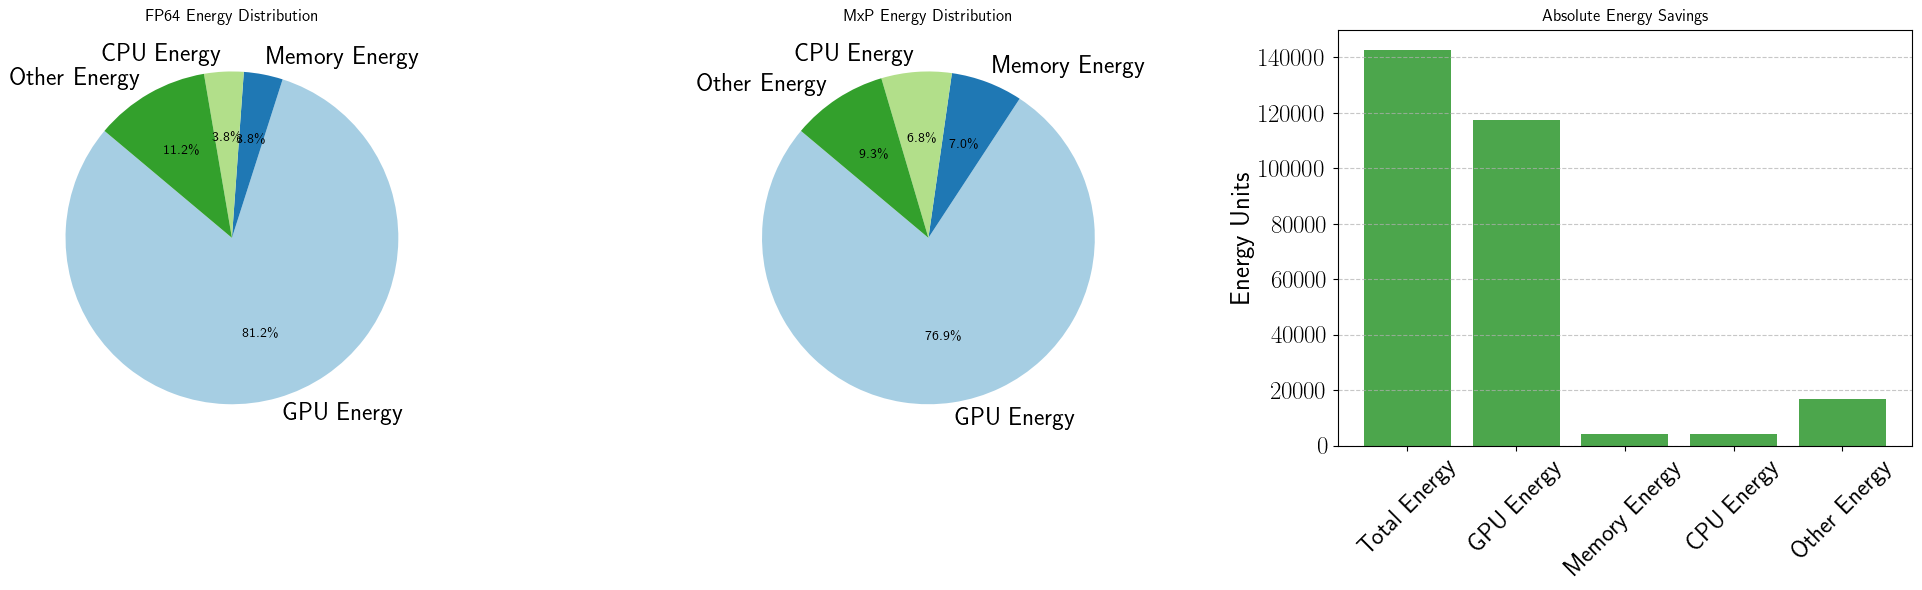

In [20]:
print_energy_savings_summary(
    rochpl := calculate_energy_savings_between_ensembles(
        mi250x_rochpl_runs,
        mi250x_rochpl_mxp_runs,
    ),
    'FP64',
    'MxP',
    'MI250X rocHPL'
)

Could not add component metric A2rocm_smi:::current_socket_power:device=0 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=1 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=2 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=3 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty


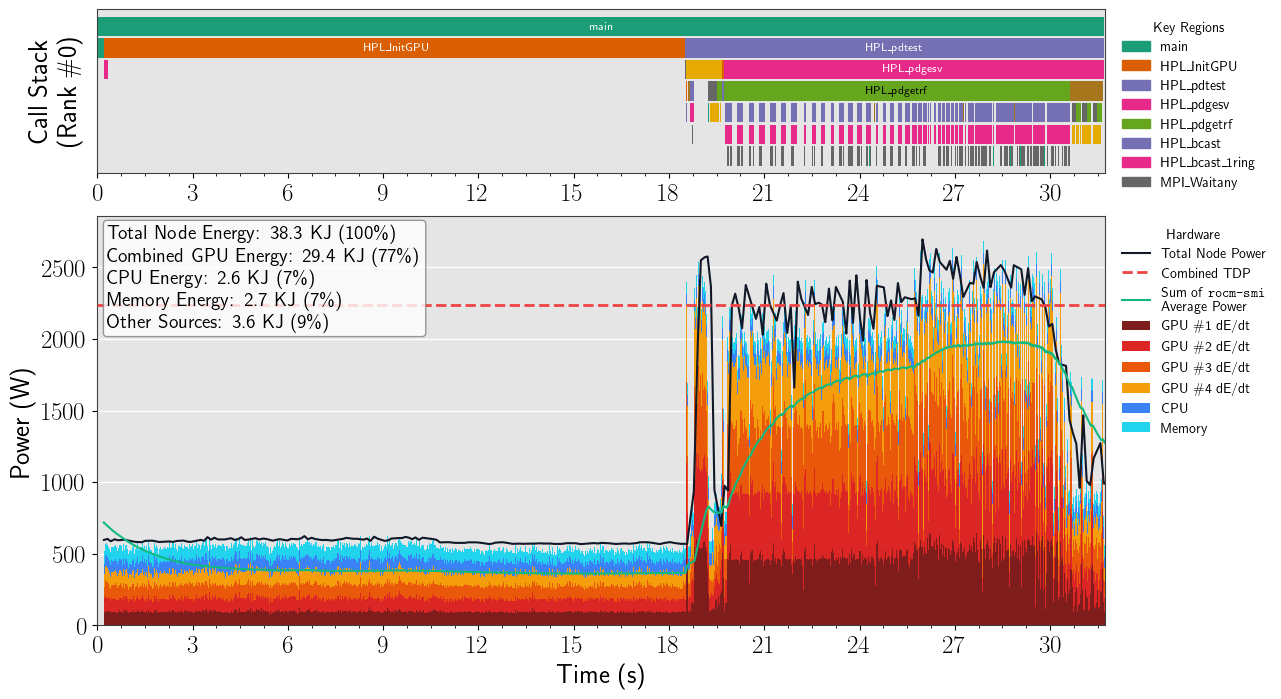

/tmp/ipykernel_1350867/2929611616.py:164: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_funcs = call_graph_df.groupby('Name')['Duration'].sum().nlargest(8).index


Could not add component metric A2rocm_smi:::current_socket_power:device=0 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=1 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=2 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=3 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty


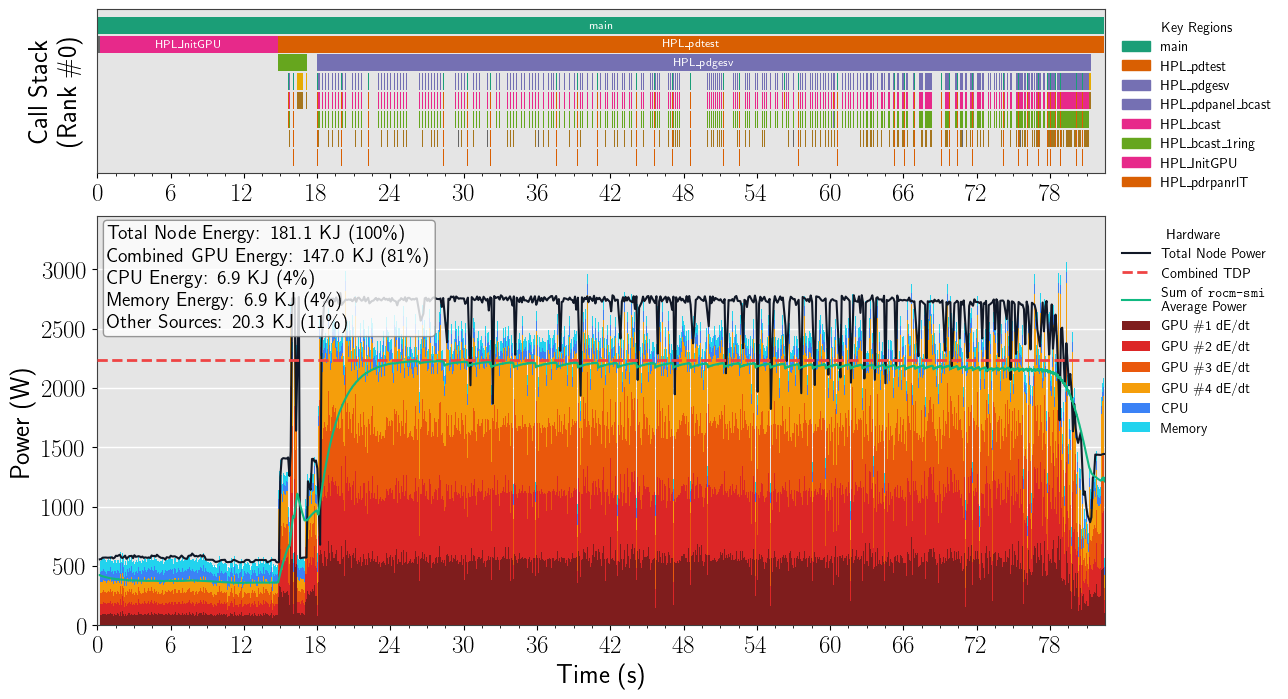

In [21]:
show_joules = lambda total: lambda x: f'{x / 1000:.1f} KJ ({(x / total) * 100:.0f}\\%)'

mxp_energy = lambda metric: rochpl[rochpl['Metric'] == metric]['Test Energy'].values[0]

f = show_joules(mxp_energy('Total Energy'))
visualize_power_of_runs_stacked_bar(
    mi250x_rochpl_mxp_runs,
    name='rocHPL-MxP (MI250X)', 
    prefix_replacements=[
        ('HPLMXP_', 'HPL_'),
        ('int HPL_', 'HPL_'),
        ('void HPL_', 'HPL_'),
        ('HPL_p', 'HPL_pd'),
        ('HPL_Warmup', 'HPL_pdwarmup')
    ],
    tdp_line=560 * 4,
    run_info=[
        f'Total Node Energy: {f(mxp_energy("Total Energy"))}',
        f'Combined GPU Energy: {f(mxp_energy("GPU Energy"))}',
        f'CPU Energy: {f(mxp_energy("CPU Energy"))}',
        f'Memory Energy: {f(mxp_energy("Memory Energy"))}',
        f'Other Sources: {f(mxp_energy("Other Energy"))}',
    ]
)

fp_energy = lambda metric: rochpl[rochpl['Metric'] == metric]['Reference Energy'].values[0]
f = show_joules(fp_energy('Total Energy'))
visualize_power_of_runs_stacked_bar(mi250x_rochpl_runs, name='rocHPL (MI250X)', tdp_line=560 * 4,
    run_info=[
        f'Total Node Energy: {f(fp_energy("Total Energy"))}',
        f'Combined GPU Energy: {f(fp_energy("GPU Energy"))}',
        f'CPU Energy: {f(fp_energy("CPU Energy"))}',
        f'Memory Energy: {f(fp_energy("Memory Energy"))}',
        f'Other Sources: {f(fp_energy("Other Energy"))}',
    ])

In [22]:
# if 'mi250x_hpg_runs' not in globals():
#     mi250x_hpg_runs = Ensemble.from_trace_paths(
#         [MI250X_TRACES.get('HPG', [])[0]],
#         MI250X_HPG_NODE_RANKS,
#     )
    
# if 'mi250x_hpg_mxp_runs' not in globals():
#     mi250x_hpg_mxp_runs = Ensemble.from_trace_paths(
#         [MI250X_TRACES.get('HPG_MXP', [])[0]],
#         MI250X_HPG_NODE_RANKS,
#     )

if 'mi300a_hpg_runs' not in globals():
    mi300a_hpg_runs = Ensemble.from_trace_paths(
        [MI300A_TRACES.get('HPG', [])[0]],
        MI300A_HPG_NODE_RANKS,
    )
    
if 'mi300a_hpg_mxp_runs' not in globals():
    mi300a_hpg_mxp_runs = Ensemble.from_trace_paths(
        [MI300A_TRACES.get('HPG_MXP', [])[0]],
        MI300A_HPG_NODE_RANKS,
    )

Calculated energy savings for 1 node runs.
{'Total Energy': np.float64(57486.0), 'GPU Energy': np.float64(36499.03078599833), 'Memory Energy': 0.0, 'CPU Energy': 0.0, 'Other Energy': np.float64(20986.96921400167)}
Calculated energy savings for 1 node runs.
{'Total Energy': np.float64(39290.0), 'GPU Energy': np.float64(26426.101484995335), 'Memory Energy': 0.0, 'CPU Energy': 0.0, 'Other Energy': np.float64(12863.898515004665)}
Baseline average energy consumption per node:


,index,0
0,Total Energy,57486.000000
1,GPU Energy,36499.030786
2,Memory Energy,0.000000
3,CPU Energy,0.000000
4,Other Energy,20986.969214


Optimized average energy consumption per node:


,index,0
0,Total Energy,39290.000000
1,GPU Energy,26426.101485
2,Memory Energy,0.000000
3,CPU Energy,0.000000
4,Other Energy,12863.898515


,Metric,FP64 Energy,MxP Energy,Energy Savings,Percent Savings
0,Total Energy,57486.00,39290.00,18196.00,31.65%
1,GPU Energy,36499.03,26426.10,10072.93,27.60%
2,Memory Energy,0.00,0.00,0.00,0.00%
3,CPU Energy,0.00,0.00,0.00,0.00%
4,Other Energy,20986.97,12863.90,8123.07,38.71%


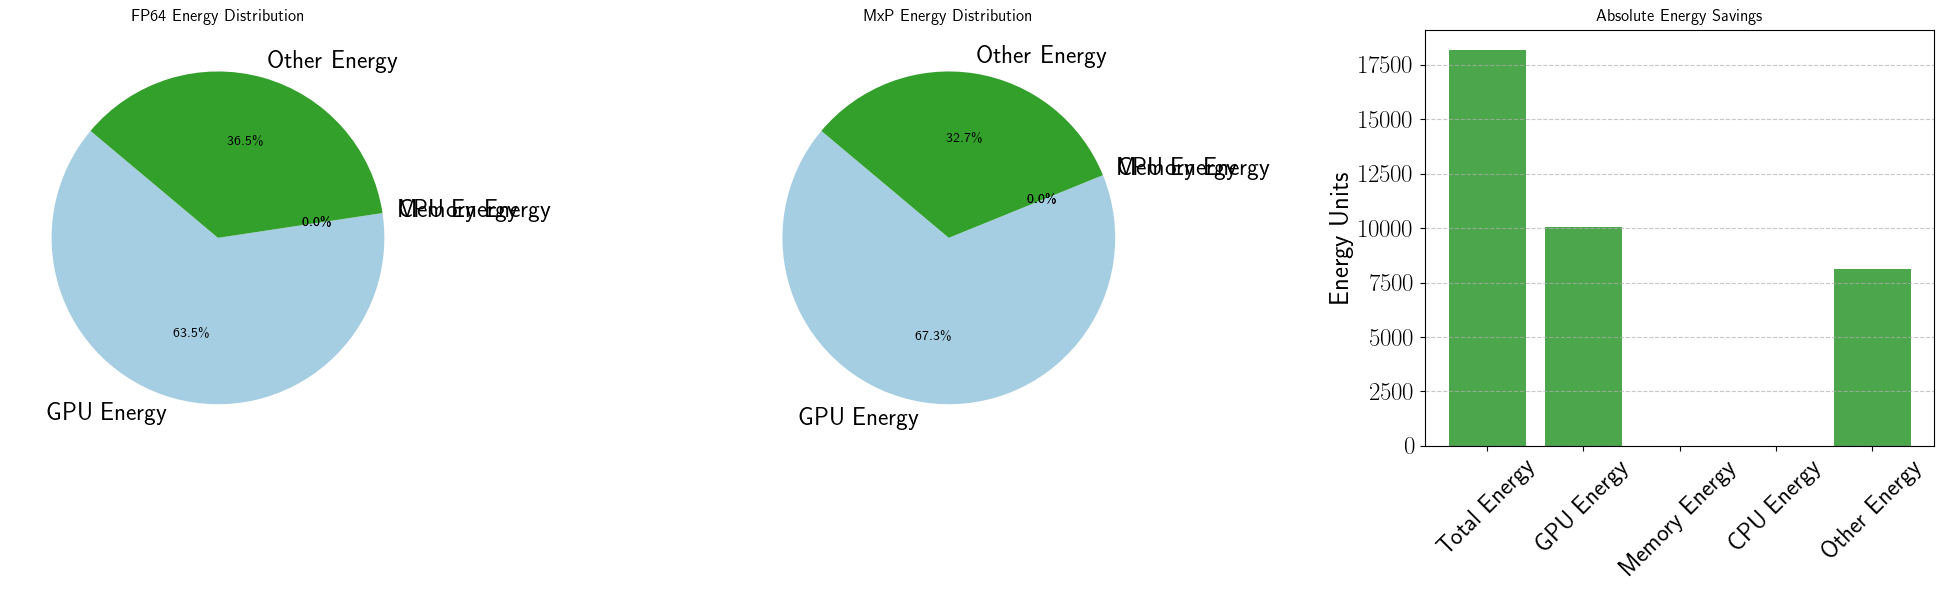

In [23]:
print_energy_savings_summary(
    hpg := calculate_energy_savings_between_ensembles(
        mi300a_hpg_runs,
        mi300a_hpg_mxp_runs,
    ),
    'FP64',
    'MxP',
    'MI300A HPG'
)

Could not add component metric A2rocm_smi:::power_average:device=0:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=2:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=4:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=6:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is em

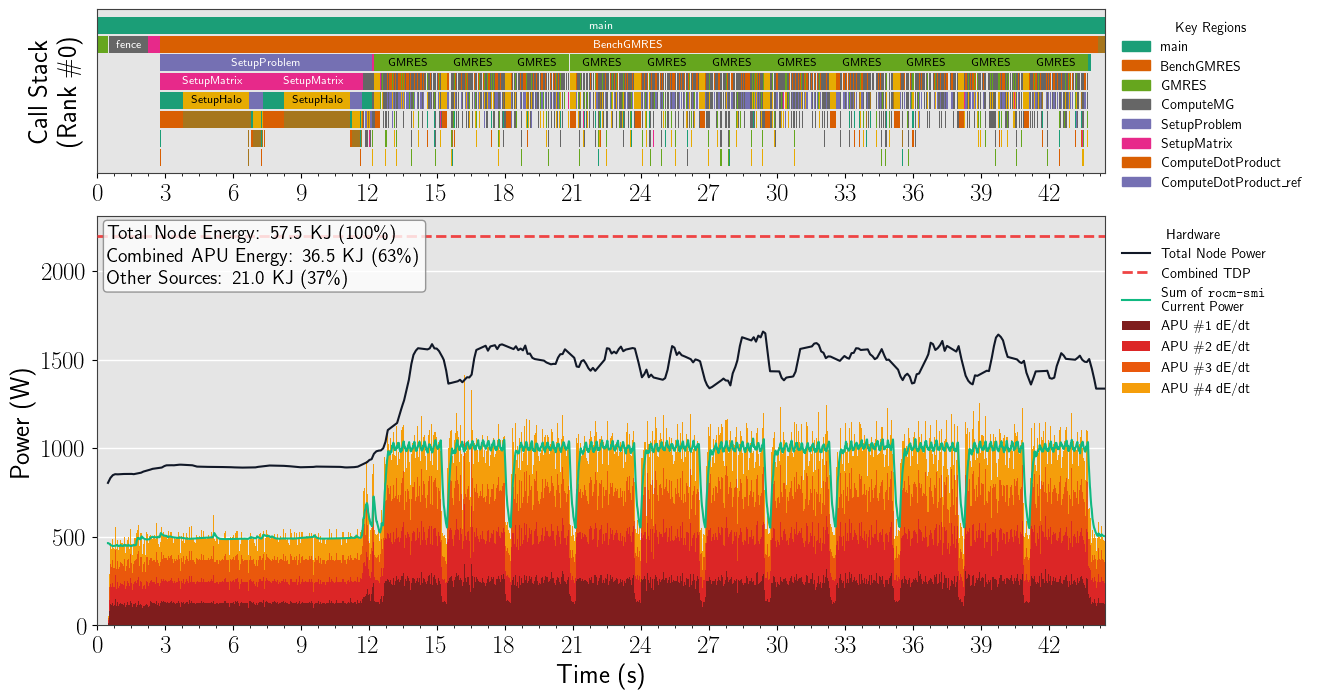

Could not add component metric A2rocm_smi:::power_average:device=0:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=2:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=4:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::power_average:device=6:sensor=0 for combined metric Sum of \texttt{rocm-smi}
Average Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=4 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is empty
Could not add component metric A2rocm_smi:::current_socket_power:device=6 for combined metric Sum of \texttt{rocm-smi}
Current Power: array of sample points is em

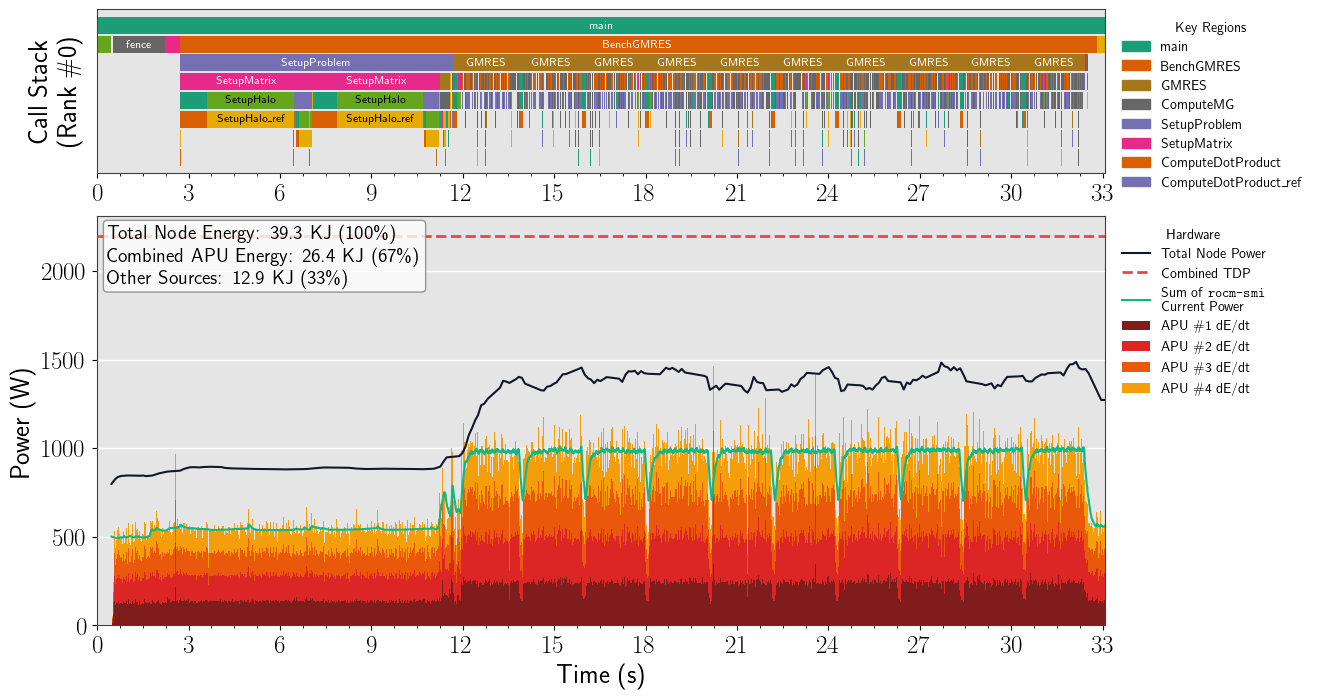

In [24]:
fp_energy = lambda metric: hpg[hpg['Metric'] == metric]['Reference Energy'].values[0]
f = show_joules(fp_energy('Total Energy'))
visualize_power_of_runs_stacked_bar(
    mi300a_hpg_runs,
    name='HPG-MxP Full Precision (MI300A)',
    prefix_replacements=[
        ('int ', ''),
        ('void ', '')
    ],
    tdp_line=550 * 4,
    accel_type='APU',
    run_info=[
        f'Total Node Energy: {f(fp_energy("Total Energy"))}',
        f'Combined APU Energy: {f(fp_energy("GPU Energy"))}',
        f'Other Sources: {f(fp_energy("Other Energy"))}',
    ]
)


mxp_energy = lambda metric: hpg[hpg['Metric'] == metric]['Test Energy'].values[0]
f = show_joules(mxp_energy('Total Energy'))
visualize_power_of_runs_stacked_bar(
    mi300a_hpg_mxp_runs,
    name='HPG-MxP Mixed Precision (MI300A)',
    prefix_replacements=[
        ('int GMRES_IR', 'int GMRES'),
        ('int ', ''),
        ('void ', '')
    ],
    tdp_line=550 * 4,
    accel_type='APU',
    run_info=[
        f'Total Node Energy: {f(mxp_energy("Total Energy"))}',
        f'Combined APU Energy: {f(mxp_energy("GPU Energy"))}',
        f'Other Sources: {f(mxp_energy("Other Energy"))}',
    ]
)

# visualize_power_of_runs_stacked_bar(
#     mi250x_hpg_runs,
#     name='HPG-MxP Full Precision (MI250X)',
#     prefix_replacements=[
#         ('int ', ''),
#         ('void ', '')
#     ],
#     tdp_line=560 * 4,
#     run_info=[
#         f'Total Node Energy: {56132.64 / 1000:.1f} KJ',
#         f'GPU Energy: {44179.30 / 1000:.1f} KJ',
#         f'CPU Energy: {4289.64 / 1000:.1f} KJ',
#         f'Memory Energy: {4465.62 / 1000:.1f} KJ',
#         f'Unattributed Energy: {3198.06 / 1000:.1f} KJ',
#     ]
# )
# visualize_power_of_runs_stacked_bar(
#     mi250x_hpg_mxp_runs,
#     name='HPG-MxP Mixed Precision (MI250X)',
#     prefix_replacements=[
#         ('int GMRES_IR', 'int GMRES'),
#         ('int ', ''),
#         ('void ', '')
#     ],
#     tdp_line=560 * 4,
#     run_info=[
#         f'Total Node Energy: {38756.18 / 1000:.1f} KJ',
#         f'GPU Energy: {30055.66 / 1000:.1f} KJ',
#         f'CPU Energy: {3349.27 / 1000:.1f} KJ',
#         f'Memory Energy: {3516.74 / 1000:.1f} KJ',
#         f'Unattributed Energy: {1834.51 / 1000:.1f} KJ',
#     ]
# )


In [25]:
# Get the end time of the notebook
NOTEBOOK_END_TIME = time.time()
print(f"Notebook end time: {NOTEBOOK_END_TIME}")
print(f"Notebook end at {NOTEBOOK_END_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_END_TIME)})")

NOTEBOOK_DURATION = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook execution time: {NOTEBOOK_DURATION:.2f} seconds")

Notebook end time: 1767628023.3434992
Notebook end at 1767628023.3434992 (2026-01-05 10:47:03.343499)
Notebook execution time: 396.48 seconds
